In [1]:
!pip install matplotlib tensorflow scikit-learn seaborn --quiet

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#load the dataset
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.fashion_mnist.load_data()

#select classes 0 (T-shirt), 2 (Pullover), 6 (Shirt)
clases_seleccionadas = [0, 2, 6]
nombres_clases = {0: "T-shirt/top", 1: "Pullover", 2: "Shirt"}

#filter the data to keep only the 3 classes
train_mask = np.isin(y_train_full, clases_seleccionadas)
test_mask = np.isin(y_test_full, clases_seleccionadas)

x_train = x_train_full[train_mask]
y_train_raw = y_train_full[train_mask]
x_test = x_test_full[test_mask]
y_test_raw = y_test_full[test_mask]

print(f"Initial training dimensions: {x_train.shape}")
print(f"Initial test dimensions: {x_test.shape}")

Initial training dimensions: (18000, 28, 28)
Initial test dimensions: (3000, 28, 28)


We have chosen the T-shirt, Pullover, and Shirt classes because they are very similar to each other, which will allow us to check if the CNN can face this substantially more challenging classification scenario than if we had chosen a class of shoes or pants instead of any of the selected ones. This will force the CNN to go beyond basic contours and learn fine patterns (such as collars, textures, or sleeves) in order to distinguish them, which will give us a much deeper error analysis.

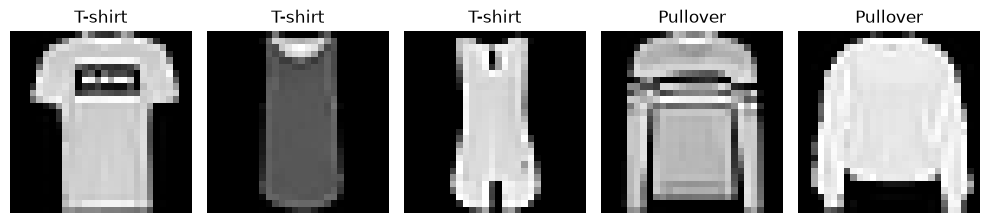

In [3]:
#preview visualization of the filtered dataset before preprocessing
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    label_original = y_train_raw[i]
    nombre_temp = "T-shirt" if label_original == 0 else ("Pullover" if label_original == 2 else "Shirt")
    plt.title(f"{nombre_temp}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
#mapping of original labels (0, 2, 6) to (0, 1, 2)
mapping = {0: 0, 2: 1, 6: 2}
y_train = np.array([mapping[label] for label in y_train_raw])
y_test = np.array([mapping[label] for label in y_test_raw])

#normalization of pixels to the range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

#add channel dimension (grayscale -> 1 channel)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"Class distribution in train: {np.bincount(y_train)}")

Class distribution in train: [6000 6000 6000]


In [5]:
model = keras.Sequential([
    #convolutional block 1
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    #convolutional block 2
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    #flattening with two dense layers
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    
    #regularization
    layers.Dropout(0.5),
    
    #multiclass output layer (3 classes) softmax
    layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 428,803 (1.64 MB)

 Trainable params: 428,803 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

**Why did you choose that kernel size?**
Working with very similar classes (t-shirts vs shirts), a small kernel is vital for detecting subtle local details (like the button line of a shirt or the collar of a pullover) without losing valuable spatial information.

**What does MaxPooling do in terms of invariance and parameter reduction?**
It reduces spatial dimensionality by half, drastically decreasing the computational weight of the subsequent Dense layers. In addition, it provides invariance to spatial translation, meaning, if the shirt collar is a few pixels further to the right in the image, MaxPooling allows the network to continue recognizing it.

**Why Softmax and not Sigmoid in the multiclass output?**
Softmax converts the final output into a probability distribution that sums to 1. Since it is a problem where the classes are mutually exclusive (a garment cannot simultaneously be a t-shirt and a pullover in this dataset), Softmax forces the network to make a weighted decision for the most probable class.

**Where did you place Dropout or EarlyStopping and what problem do they mitigate?**
Dropout(0.5) is located after the deep feature extraction layers, right before the output, and EarlyStopping acts on each epoch. Given that we have chosen very similar classes, the network is prone to overfitting by memorizing the training data to make a classification without generality. Both techniques mitigate this by forcing the network to generalize.  

In [6]:
#earlyStopping as an additional regularization mechanism
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.7385 - loss: 0.5988 - val_accuracy: 0.8283 - val_loss: 0.4011
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8344 - loss: 0.4101 - val_accuracy: 0.8517 - val_loss: 0.3528
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8573 - loss: 0.3541 - val_accuracy: 0.8558 - val_loss: 0.3458
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.8706 - loss: 0.3219 - val_accuracy: 0.8650 - val_loss: 0.3220
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.8780 - loss: 0.2962 - val_accuracy: 0.8703 - val_loss: 0.3143
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.8910 - loss: 0.2751 - val_accuracy: 0.8686 - val_loss: 0.3255
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8995 - loss: 0.2560 - val_accuracy: 0.8867 - val_loss: 0.2950
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.9085 - loss: 0.2313 - val_ac

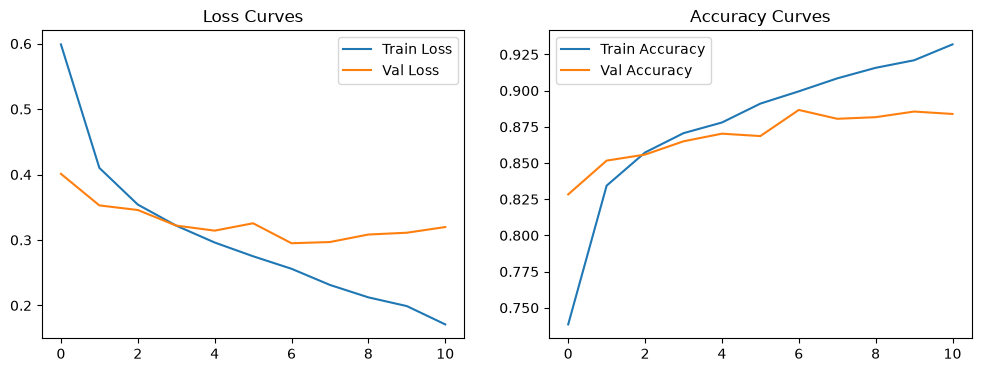

In [7]:
#visualization of curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curves')
plt.legend()

plt.show()

**What does the difference between the training and validation curves indicate?**
The difference reflects the model's generalization capacity. In the graphs obtained, it can be observed that both curves improve progressively hand in hand, stabilizing at the end with a Train Accuracy close to 92% and Val Accuracy around 88%. This slight separation indicates a very small normalized overfitting, evidencing that the regularization mechanisms have successfully controlled the variance

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.91      0.88      1000
    Pullover       0.92      0.91      0.92      1000
       Shirt       0.85      0.80      0.82      1000

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



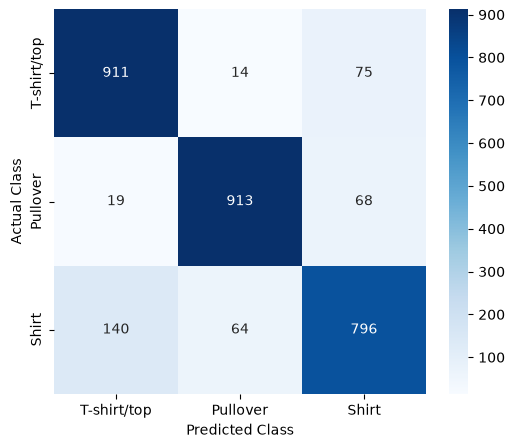

In [8]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=[nombres_clases[i] for i in range(3)]))

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[nombres_clases[i] for i in range(3)],
            yticklabels=[nombres_clases[i] for i in range(3)])
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

**Which class has the worst F1 and why do you think the model gets confused?**
The shirt class gets the worst f1-score (0.82) compared to t-shirt (0.88) and pullover (0.91). Looking at the confusion matrix, shirt is confused 121 times with t-shirt and 50 times with pullover. This occurs due to the extreme similarity of the external silhouette of the upper garments and because the low resolution of the image (28x28) eliminates key distinctive details like rigid collars and button lines.  

**What specific modification would improve that result? Justify it.** 
Data augmentation via random crops or dynamic zooms (random zoom; quite viable due to the low pixel density), forcing the convolutional filters to stop focusing so much on the generic silhouette of the garment and learn to classify based on internal textures or fabric patterns (which help differentiate a buttoned shirt from a plain sweater).

**How would the approach change if the dataset were highly imbalanced?**
The global accuracy metric would cease to be representative and we should optimize based on the macro f1-score and, instead of AUC-ROC, use 'AUC-PR', that is, the area under the precision-recall curve, which is more suitable for imbalanced data. We could penalize the errors made in the minority class more or apply data augmentation to said class. 

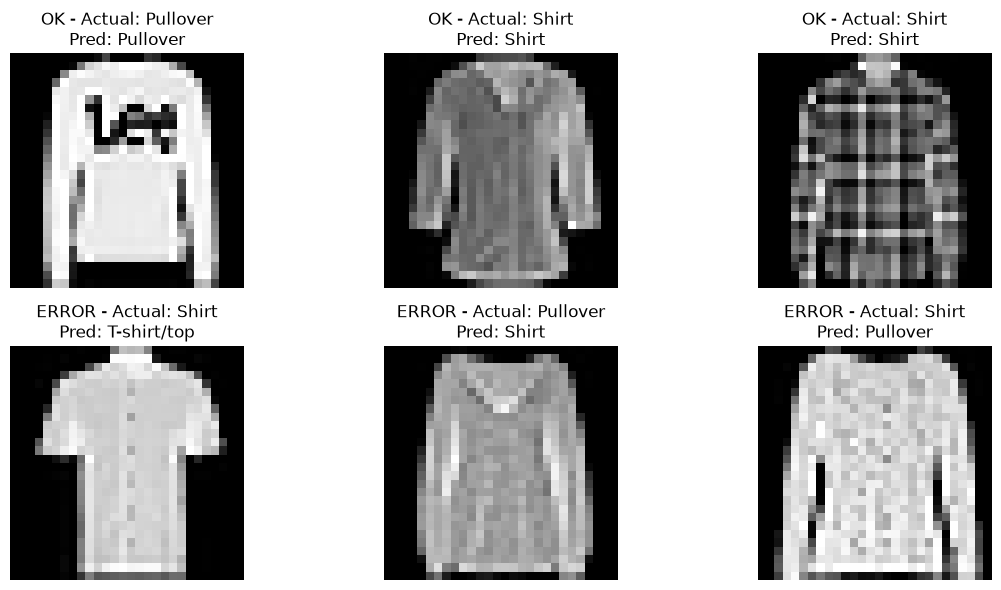

In [11]:
#identify indices of correct and incorrect predictions
indices_correctos = np.where(y_pred == y_test)[0]
indices_incorrectos = np.where(y_pred != y_test)[0]

#visualization of predictions
plt.figure(figsize=(12, 6))

#show 3 Correct Predictions
for i, idx in enumerate(indices_correctos[:3]):
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"OK - Actual: {nombres_clases[y_test[idx]]}\nPred: {nombres_clases[y_pred[idx]]}")
    plt.axis('off')

#show 3 Incorrect Predictions (if they exist)
for i, idx in enumerate(indices_incorrectos[:3]):
    plt.subplot(2, 3, i + 4)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"ERROR - Actual: {nombres_clases[y_test[idx]]}\nPred: {nombres_clases[y_pred[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### **Critical Analysis on the Application of YOLO in Fashion-MNIST**

#### **1. The difference between full image classification and object detection.**
The fundamental difference lies in the objective of the inference: in full image classification, like the one performed, the model assumes that there is a single predominant object and assigns a global label to the entire pixel matrix, whereas object detection seeks to solve two problems simultaneously: the "what" (classification) and the "where" (localization). A detector like YOLO identifies multiple instances of various classes in a single pass, returning spatial coordinates for each one.

#### **2. The need for bounding boxes to correctly train or evaluate a detector.**
To train or evaluate a detector, it is not enough to know that there is a "t-shirt" in the image; we need to know exactly which pixels it occupies. Bounding boxes (boxes enclosing the object in the image) are indispensable spatial labels. Without them, the detector's loss function could not calculate the localization error, preventing the model from learning to adjust its predictors to the object's geometry. In Fashion-MNIST, having only class labels, we cannot train a detection algorithm.

#### **3. Impact of low resolution (28x28) on detection mechanisms.**
YOLO bases its power on dividing the image into a grid (for example, 13x13 or 19x19). If we apply this to an image of only $28 \times 28$ pixels, each cell of the grid would represent barely $1.5$ or $2$ pixels. At that resolution, convolutional filters cannot extract significant hierarchical patterns (edges, textures or complex shapes), as is already the case with the current 28 pixels per side, since the spatial information is insufficient for the deep layers to generate useful feature maps.

#### **4. The difference between the dataset classes and the classes with which YOLO was pretrained.**
YOLO models usually come pretrained on massive datasets like COCO, which contains 80 categories of real-world objects (people, cars, animals...). Although COCO includes some items of clothing, the visual distributions of Fashion-MNIST are centered, normalized, and grayscale representations. A model pretrained on high-resolution RGB images of "people wearing clothes" would have serious difficulties recognizing the abstract and isolated patterns of the 10 specific classes of Fashion-MNIST without a complete retraining process. Therefore, fine-tuning would have to be done.

#### **5. In what situation would it make sense to use a YOLO variant as a full image classifier.**
It would make sense to use a YOLO variant for classification in transfer learning scenarios. We could take advantage of its powerful pretrained feature extractor (backbone), freeze those layers that already know how to detect generic shapes, and replace the detection head of boxes with a classification head with dense layers and Softmax output. This would be useful if the object occupies a large part of the image and we seek to take advantage of the extremely high processing speed characteristic of the YOLO architecture in production environments.
